<a href="https://colab.research.google.com/github/Blurryfacce/Sistema_Recomendacion_Productos/blob/main/morales_cocoa_recomendador_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍫 Morales Cocoa — Sistema de Recomendación de Producto
**Modelos:** KNN + ANN (Keras) | **Dataset:** Sintético

In [ ]:
import numpy as np
import pandas as pd
import random
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TF:", tf.__version__, "| OK ✓")


TF: 2.20.0 | OK ✓


## 1. Catálogo de productos

In [ ]:
PRODUCTS = {
    0:  ("55% Leche - Almendra",     "leche",  "frutos_secos", 55),
    1:  ("55% Leche - Canela",       "leche",  "especias",     55),
    2:  ("55% Leche - Hierba Luisa", "leche",  "herbal",       55),
    3:  ("55% Leche - Maracuyá",     "leche",  "tropical",     55),
    4:  ("55% Leche - Menta",        "leche",  "mentolado",    55),
    5:  ("55% Leche - Naranja",      "leche",  "cítrico",      55),
    6:  ("75% Oscuro - Almendra",    "oscuro", "frutos_secos", 75),
    7:  ("75% Oscuro - Canela",      "oscuro", "especias",     75),
    8:  ("75% Oscuro - Hierba Luisa","oscuro", "herbal",       75),
    9:  ("75% Oscuro - Menta",       "oscuro", "mentolado",    75),
}

FLAVORS    = ["frutos_secos", "especias", "herbal", "tropical", "mentolado", "cítrico"]
CATEGORIES = ["leche", "oscuro"]

for pid, (name, cat, flavor, cacao) in PRODUCTS.items():
    print(f"[{pid}] {name}")


[0] 55% Leche - Almendra
[1] 55% Leche - Canela
[2] 55% Leche - Hierba Luisa
[3] 55% Leche - Maracuyá
[4] 55% Leche - Menta
[5] 55% Leche - Naranja
[6] 75% Oscuro - Almendra
[7] 75% Oscuro - Canela
[8] 75% Oscuro - Hierba Luisa
[9] 75% Oscuro - Menta


## 2. Generación de datos sintéticos

**Features:**
- `cat_preference` — 0=leche, 1=oscuro (filtro usado en catálogo)
- `flavor_preference` — 0-5 (sabor más clickeado)
- `items_in_cart` — cantidad de barras distintas en carrito
- `subtotal` — monto acumulado en USD
- `time_on_catalog_s` — segundos en página de catálogo
- `viewed_detail` — 1 si abrió detalle de producto
- `cacao_avg_cart` — promedio % cacao de los items en carrito

**Target:** `recommended_product` — id del producto comprado (0-9)

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
N_SAMPLES = 8000

def generate_session(n=N_SAMPLES):
    rows = []
    for _ in range(n):
        cat_pref = 0 if random.random() < 0.60 else 1

        # Preferencia de sabor correlacionada con la categoría
        if cat_pref == 0:   # leche → más tropical/cítrico
            flavor_pref = random.choices(range(6),
                weights=[0.15, 0.10, 0.10, 0.35, 0.15, 0.15])[0]
        else:               # oscuro → más especias/herbal
            flavor_pref = random.choices(range(6),
                weights=[0.20, 0.30, 0.25, 0.05, 0.15, 0.05])[0]

        items_in_cart   = random.randint(0, 8)
        subtotal        = max(0.0, round(items_in_cart * 2.50 + random.uniform(-0.5, 2.0), 2))
        time_on_catalog = random.randint(10, 300)
        viewed_detail   = random.randint(0, 1)
        cacao_avg       = round((55 if cat_pref == 0 else 75) + random.uniform(-5, 5), 1)

        # Target: producto comprado (con peso al que coincide en categoría + sabor)
        cat_name    = CATEGORIES[cat_pref]
        flavor_name = FLAVORS[flavor_pref]
        candidates  = [pid for pid, (_, c, _, _) in PRODUCTS.items() if c == cat_name]
        weights     = [0.70 if PRODUCTS[pid][2] == flavor_name
                       else 0.30 / (len(candidates) - 1)
                       for pid in candidates]
        total_w     = sum(weights)
        weights     = [w / total_w for w in weights]
        target      = random.choices(candidates, weights=weights)[0]

        rows.append({
            "cat_preference":      cat_pref,
            "flavor_preference":   flavor_pref,
            "items_in_cart":       items_in_cart,
            "subtotal":            subtotal,
            "time_on_catalog_s":   time_on_catalog,
            "viewed_detail":       viewed_detail,
            "cacao_avg_cart":      cacao_avg,
            "recommended_product": target
        })
    return pd.DataFrame(rows)

df = generate_session()
print(f"Dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()


Dataset: 8000 filas × 8 columnas


,cat_preference,flavor_preference,items_in_cart,subtotal,time_on_catalog_s,viewed_detail,cacao_avg_cart,recommended_product
0,1,0,4,10.11,81,0,76.8,8
1,0,3,0,0.00,129,0,55.6,3
2,1,1,7,18.47,13,0,77.0,7
3,0,5,5,12.26,204,0,53.6,5
4,0,0,7,18.34,203,0,55.5,3


## 3. Preprocesamiento

In [ ]:
X = df.drop("recommended_product", axis=1)
Y = df["recommended_product"]

scaler  = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.20, random_state=SEED, stratify=Y
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Clases: {sorted(Y.unique())}")


Train: 6400 | Test: 1600
Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


## 4. Modelo 1 — KNN

Mejor K = 12  →  Accuracy = 0.6581


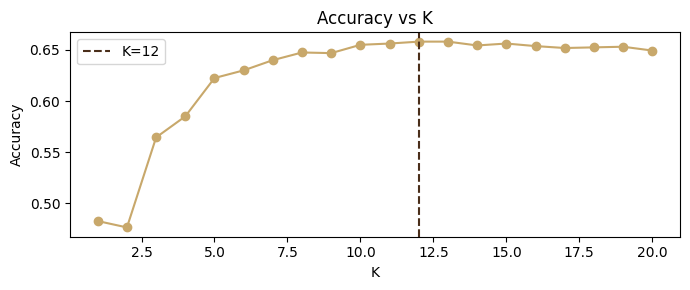

In [ ]:
k_range  = range(1, 21)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train, Y_train)
    k_scores.append(accuracy_score(Y_test, knn.predict(X_test)))

best_k = list(k_range)[np.argmax(k_scores)]
print(f"Mejor K = {best_k}  →  Accuracy = {max(k_scores):.4f}")

plt.figure(figsize=(7, 3))
plt.plot(list(k_range), k_scores, marker="o", color="#C8A86B")
plt.axvline(best_k, linestyle="--", color="#4A2E1A", label=f"K={best_k}")
plt.xlabel("K"); plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.legend(); plt.tight_layout(); plt.show()


                           precision    recall  f1-score   support

     55% Leche - Almendra       0.60      0.68      0.64       141
       55% Leche - Canela       0.75      0.41      0.53       125
 55% Leche - Hierba Luisa       0.76      0.59      0.66       110
     55% Leche - Maracuyá       0.65      0.83      0.73       272
        55% Leche - Menta       0.69      0.54      0.60       145
      55% Leche - Naranja       0.64      0.72      0.68       160
    75% Oscuro - Almendra       0.69      0.62      0.65       151
      75% Oscuro - Canela       0.68      0.72      0.70       193
75% Oscuro - Hierba Luisa       0.66      0.69      0.68       173
       75% Oscuro - Menta       0.56      0.55      0.55       130

                 accuracy                           0.66      1600
                macro avg       0.67      0.63      0.64      1600
             weighted avg       0.66      0.66      0.65      1600



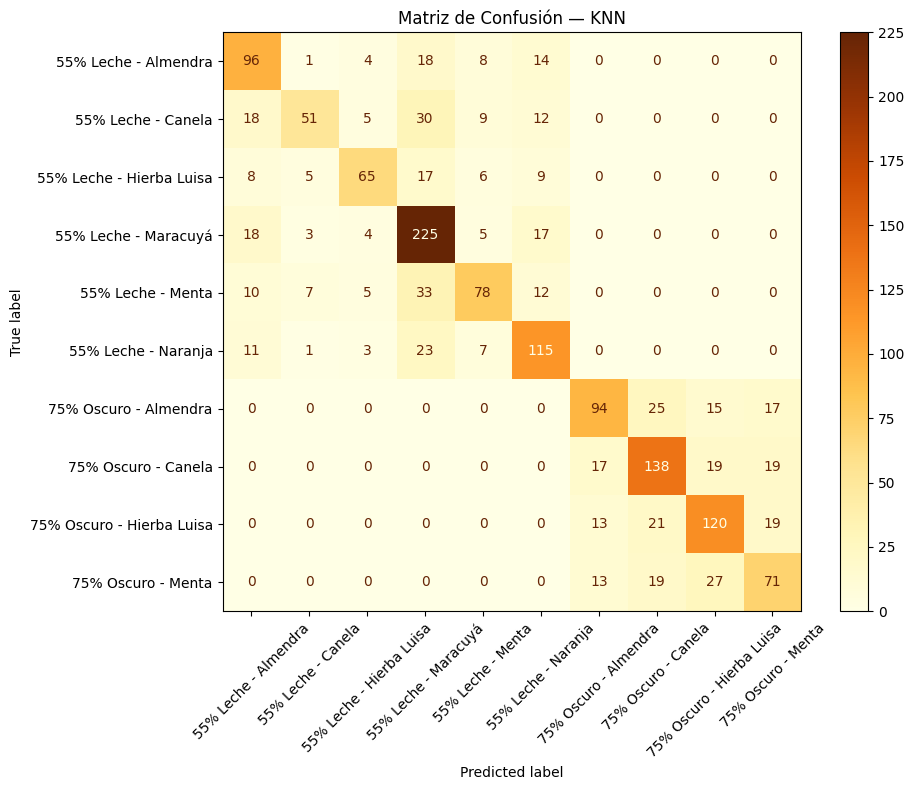

In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_best.fit(X_train, Y_train)
knn_pred = knn_best.predict(X_test)

print(classification_report(Y_test, knn_pred,
      target_names=[PRODUCTS[i][0] for i in sorted(Y.unique())]))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix(Y_test, knn_pred),
    display_labels=[PRODUCTS[i][0] for i in sorted(Y.unique())]
).plot(ax=ax, cmap="YlOrBr", xticks_rotation=45)
ax.set_title("Matriz de Confusión — KNN")
plt.tight_layout(); plt.show()


## 5. Modelo 2 — ANN (Keras)

In [ ]:
n_classes  = len(Y.unique())
n_features = X_train.shape[1]

ann = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(n_classes, activation="softmax")
])
ann.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])
ann.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,290 (12.85 KB)

 Trainable params: 3,290 (12.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = ann.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10,
                             restore_best_weights=True)],
    verbose=1
)


Epoch 1/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2287 - loss: 1.9853 - val_accuracy: 0.2948 - val_loss: 1.6134
Epoch 2/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3274 - loss: 1.5593 - val_accuracy: 0.4458 - val_loss: 1.4722
Epoch 3/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4169 - loss: 1.4601 - val_accuracy: 0.5302 - val_loss: 1.4022
Epoch 4/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4665 - loss: 1.3967 - val_accuracy: 0.5052 - val_loss: 1.3467
Epoch 5/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4877 - loss: 1.3555 - val_accuracy: 0.5406 - val_loss: 1.3146
Epoch 6/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5143 - loss: 1.3230 - val_accuracy: 0.6062 - val_loss: 1.2834
Epoch 7/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5504 - loss: 1.3018 - val_accuracy: 0.5750 - val_loss: 1.2672
Epoch 8/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5699 - loss: 1.2777 - val_acc

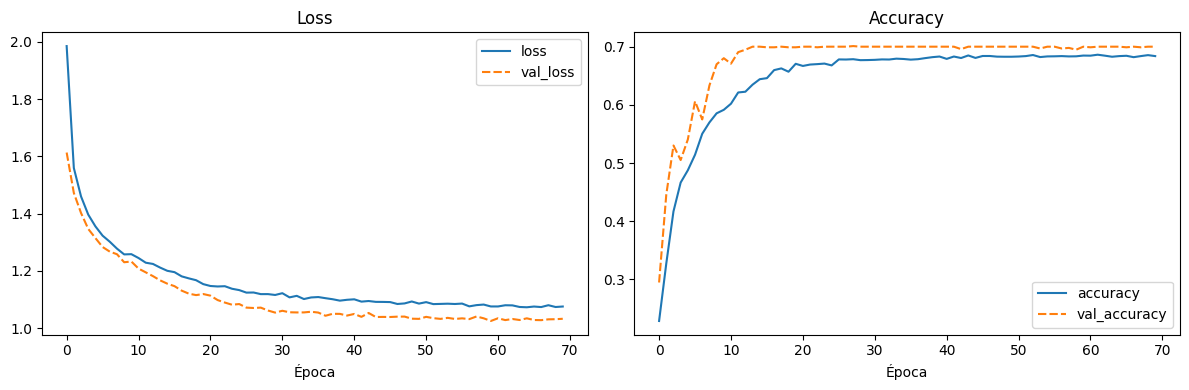

In [ ]:
loss_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=loss_df[["loss", "val_loss"]], ax=axes[0])
axes[0].set_title("Loss"); axes[0].set_xlabel("Época")

sns.lineplot(data=loss_df[["accuracy", "val_accuracy"]], ax=axes[1])
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Época")

plt.tight_layout(); plt.show()


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                           precision    recall  f1-score   support

     55% Leche - Almendra       0.61      0.69      0.65       141
       55% Leche - Canela       0.79      0.44      0.56       125
 55% Leche - Hierba Luisa       0.75      0.63      0.68       110
     55% Leche - Maracuyá       0.67      0.83      0.74       272
        55% Leche - Menta       0.69      0.56      0.62       145
      55% Leche - Naranja       0.64      0.72      0.68       160
    75% Oscuro - Almendra       0.70      0.61      0.65       151
      75% Oscuro - Canela       0.69      0.68      0.68       193
75% Oscuro - Hierba Luisa       0.69      0.68      0.69       173
       75% Oscuro - Menta       0.53      0.62      0.57       130

                 accuracy                           0.67      1600
                macro avg       0.68      0.65      0.65      1600
             weighted avg       0.67      0.67      0.66      1600



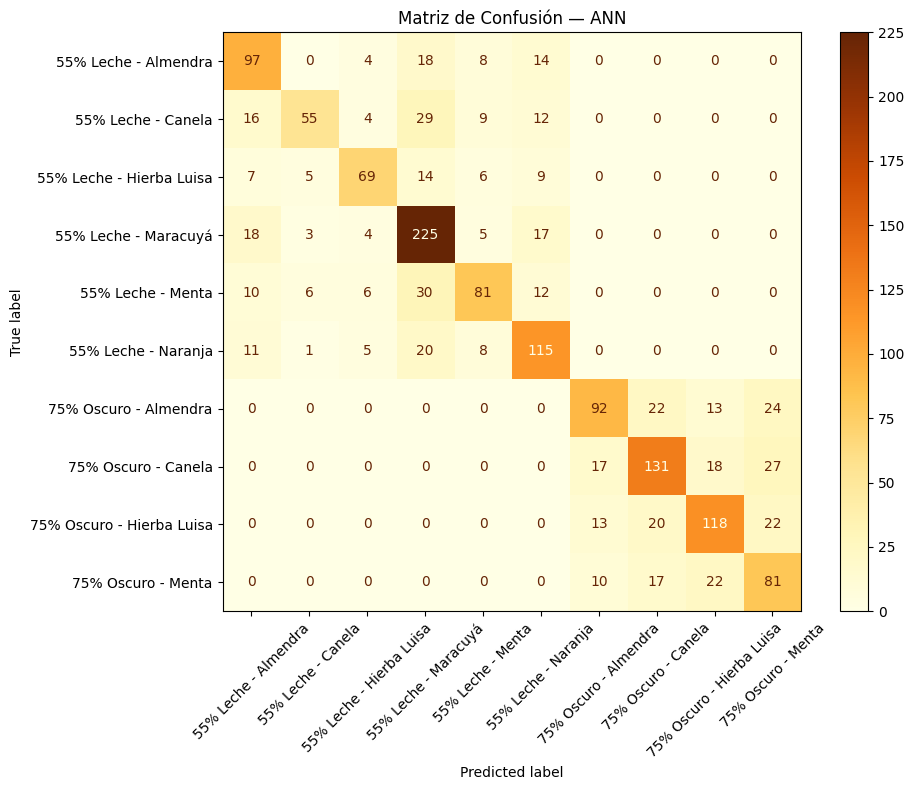

In [ ]:
ann_pred = np.argmax(ann.predict(X_test), axis=1)

print(classification_report(Y_test, ann_pred,
      target_names=[PRODUCTS[i][0] for i in sorted(Y.unique())]))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix(Y_test, ann_pred),
    display_labels=[PRODUCTS[i][0] for i in sorted(Y.unique())]
).plot(ax=ax, cmap="YlOrBr", xticks_rotation=45)
ax.set_title("Matriz de Confusión — ANN")
plt.tight_layout(); plt.show()


## 6. Comparativa KNN vs ANN

     Modelo  Accuracy
 KNN (K=12)    0.6581
ANN (Keras)    0.6650


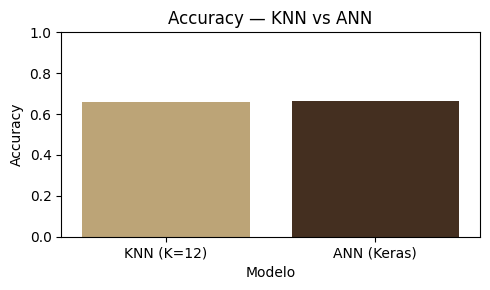

In [ ]:
acc_knn = accuracy_score(Y_test, knn_pred)
acc_ann = accuracy_score(Y_test, ann_pred)

results = pd.DataFrame({
    "Modelo":   [f"KNN (K={best_k})", "ANN (Keras)"],
    "Accuracy": [round(acc_knn, 4), round(acc_ann, 4)]
})
print(results.to_string(index=False))

plt.figure(figsize=(5, 3))
sns.barplot(data=results, x="Modelo", y="Accuracy",
            palette=["#C8A86B", "#4A2E1A"])
plt.ylim(0, 1)
plt.title("Accuracy — KNN vs ANN")
plt.tight_layout(); plt.show()


## 7. Demo — función de recomendación

In [ ]:
def recomendar(cat_preference, flavor_preference, items_in_cart,
               subtotal, time_on_catalog_s, viewed_detail, cacao_avg_cart,
               top_n=3):
    row = pd.DataFrame([[cat_preference, flavor_preference, items_in_cart,
                         subtotal, time_on_catalog_s, viewed_detail, cacao_avg_cart]],
                       columns=X.columns)
    probs       = ann.predict(scaler.transform(row), verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:top_n]

    print(f"Preferencia: {'Leche 55%' if cat_preference==0 else 'Oscuro 75%'}"
          f" | Sabor: {FLAVORS[flavor_preference]}"
          f" | Carrito: {items_in_cart} items (${subtotal:.2f})")
    print()
    for rank, pid in enumerate(top_indices, 1):
        bar = "█" * int(probs[pid] * 30)
        print(f"  #{rank}  {PRODUCTS[pid][0]:<35}  {probs[pid]:.1%}  {bar}")

# Ejemplo 1 — leche + tropical
print("── Ejemplo 1 ──────────────────────────────")
recomendar(0, 3, 2, 5.00, 90, 1, 55.0)

# Ejemplo 2 — oscuro + especias
print("── Ejemplo 2 ──────────────────────────────")
recomendar(1, 1, 4, 10.00, 200, 1, 75.0)

# Ejemplo 3 — cold start
print("── Ejemplo 3 (cold start) ─────────────────")
recomendar(0, 5, 0, 0.0, 15, 0, 55.0)


── Ejemplo 1 ──────────────────────────────
Preferencia: Leche 55% | Sabor: tropical | Carrito: 2 items ($5.00)

  #1  55% Leche - Maracuyá                 69.6%  ████████████████████
  #2  55% Leche - Hierba Luisa             7.8%  ██
  #3  55% Leche - Almendra                 5.9%  █
── Ejemplo 2 ──────────────────────────────
Preferencia: Oscuro 75% | Sabor: especias | Carrito: 4 items ($10.00)

  #1  75% Oscuro - Canela                  71.8%  █████████████████████
  #2  75% Oscuro - Almendra                10.3%  ███
  #3  75% Oscuro - Menta                   9.4%  ██
── Ejemplo 3 (cold start) ─────────────────
Preferencia: Leche 55% | Sabor: cítrico | Carrito: 0 items ($0.00)

  #1  55% Leche - Naranja                  74.4%  ██████████████████████
  #2  55% Leche - Almendra                 6.9%  ██
  #3  55% Leche - Canela                   6.4%  █


In [ ]:
# Guardar modelo
ann.save("model.h5")

# Guardar el scaler
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)